In [1]:
import pandas as pd
import sklearn.cluster as cluster
import matplotlib.pyplot as plt

In [2]:
#Učitavamo dataset sa svim podacima i oučavamo kolone kao i tipove kolona
#Dakle vidimo da imamo 15 kolona od kojih su većina numeričke izuzev kolona Gender i Workout_Type
df_svi_clanovi = pd.read_csv('./data/gym_members_exercise_tracking.csv')
df_svi_clanovi.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [3]:
#Prikaz nekoliko redova samog dataset-a
df_svi_clanovi.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [4]:
#Dataset ćemo podeliti na dva podskupa  (Male, Female) - klasterizaciju ćemo sprovesti odvojeno za svaki podskup, s obzirom da se telesni parametri muških i ženskih članova značajno razlikuju.U ovoj skripti će biti opisana klasterizacija za ženske članove.

zenski_clanovi = df_svi_clanovi[df_svi_clanovi["Gender"] == "Female"].copy()

In [5]:
#Sada vršimo ponovo pregled kolona i vidimo drugi broj redova,budući da više nemamo redove za muške članove
zenski_clanovi.info()
zenski_clanovi.head(20)

<class 'pandas.DataFrame'>
Index: 462 entries, 1 to 970
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            462 non-null    int64  
 1   Gender                         462 non-null    str    
 2   Weight (kg)                    462 non-null    float64
 3   Height (m)                     462 non-null    float64
 4   Max_BPM                        462 non-null    int64  
 5   Avg_BPM                        462 non-null    int64  
 6   Resting_BPM                    462 non-null    int64  
 7   Session_Duration (hours)       462 non-null    float64
 8   Calories_Burned                462 non-null    float64
 9   Workout_Type                   462 non-null    str    
 10  Fat_Percentage                 462 non-null    float64
 11  Water_Intake (liters)          462 non-null    float64
 12  Workout_Frequency (days/week)  462 non-null    int64  
 13  Experi

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
15,39,Female,42.5,1.75,181,131,52,1.13,740.0,Strength,26.2,2.1,2,1,13.88
16,19,Female,64.0,1.53,166,167,58,1.33,1111.0,HIIT,29.8,2.3,3,2,27.34
17,41,Female,43.8,1.77,182,165,58,1.19,884.0,Cardio,31.9,1.6,3,1,13.98
18,47,Female,66.8,1.75,199,146,56,1.13,742.0,Strength,32.8,2.5,3,2,21.81
19,55,Female,75.2,1.67,188,167,51,1.37,1030.0,HIIT,25.2,2.2,2,1,26.96
22,50,Female,71.0,1.68,187,161,70,1.17,848.0,Yoga,33.1,2.5,2,1,25.16


In [6]:
#Sada kada dataset ima samo ženske članove, prelazimo na sređivanje podataka, prvo ćemo razmotriti koje kolone bi možda trebalo izbaciti
#Prva kolona koju bi izbacili jeste Gender, nema smisla zadržati je posto su joj sve vrednosti iste, jer smo tako podelili dataset, zbog što validnijih rezultata klasterizacije
#Workout_Type izbacujemo jer je tekstualna promenljiva (tip treninga) bez pravog redosleda.Kad bismo je pretvorili u brojeve, algoritam bi te brojeve shvatio kao rastojanja među kategorijama, a to nema smisla jer npr. "Yoga" nije bliža od "HIIT-a" na neki realan nacin, nije realno porediti.
#Experience_Level izbacujemo iz klasterizacije jer zelimo da pronađemo grupe na osnovu fizičkih parametara, bez da unapred znamo koji je nivo iskustva - kasnije ćemo dobijene klastere uporediti sa ovom kolonom da vidimo da li se poklapaju, zato, je odvajamo sa strane
experience_level = zenski_clanovi['Experience_Level']
#Izbacujemo te tri kolone i vršimo ponovo pregled dataset-a:
zenski_clanovi.drop(columns=["Gender", "Workout_Type", "Experience_Level"], inplace=True)

zenski_clanovi.info()

<class 'pandas.DataFrame'>
Index: 462 entries, 1 to 970
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            462 non-null    int64  
 1   Weight (kg)                    462 non-null    float64
 2   Height (m)                     462 non-null    float64
 3   Max_BPM                        462 non-null    int64  
 4   Avg_BPM                        462 non-null    int64  
 5   Resting_BPM                    462 non-null    int64  
 6   Session_Duration (hours)       462 non-null    float64
 7   Calories_Burned                462 non-null    float64
 8   Fat_Percentage                 462 non-null    float64
 9   Water_Intake (liters)          462 non-null    float64
 10  Workout_Frequency (days/week)  462 non-null    int64  
 11  BMI                            462 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 46.9 KB


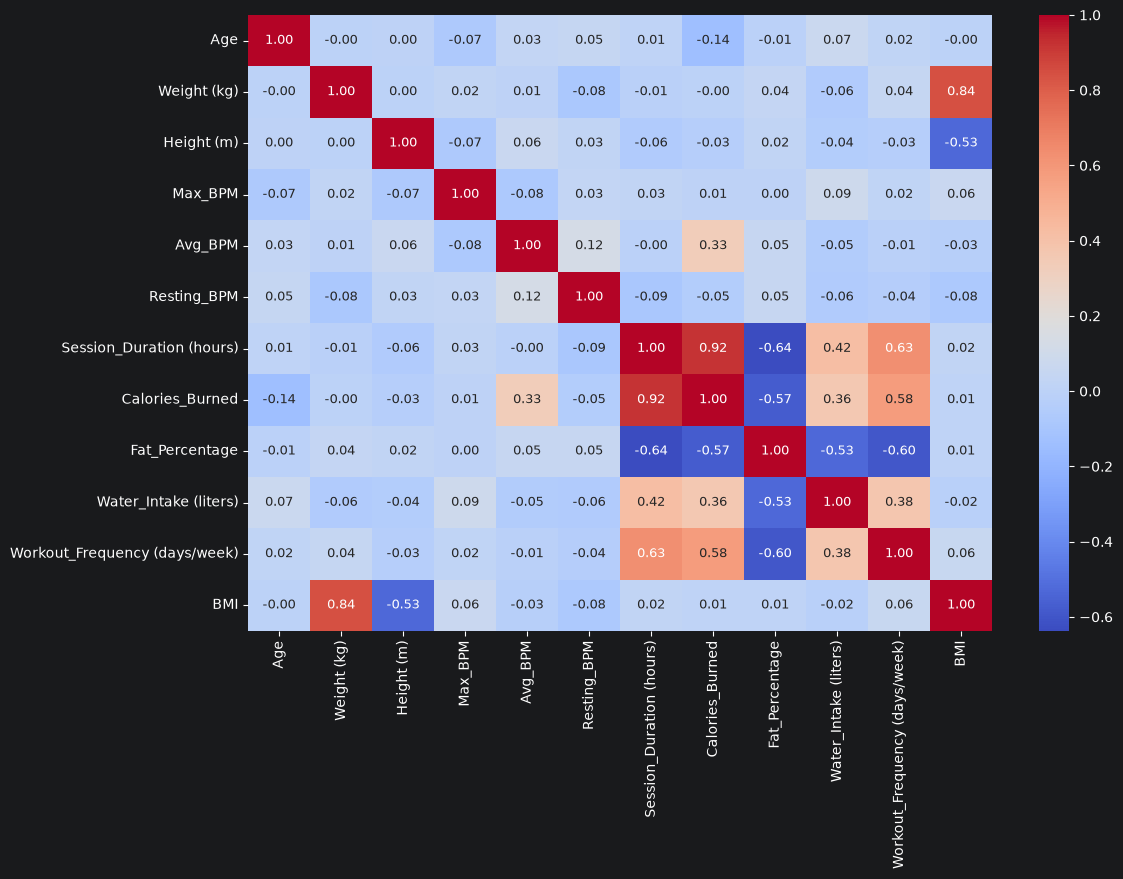

In [7]:
import seaborn as sb
#Što se tiče dalje pripreme podataka trebali bi da obratimo pažnju na NaN vrednosti ali u ovom dataset-u vidimo da istih nema ali važno je napomenuti da u slučaju da postoje NaN vrednosti, to bi se tretiralo na jedan od sledećih načina:
# 1.Izbacivanjem celih redova(ako neki red ima puno nedostajućih vrednosti)
# 2.Izbacivanjem celih promenljivih (ako neka promenljiva ima puno NaN vrednosti)
# 3.Zamenom NaN vrednosti npr. medijanom ili prosekom za tu promenljivu
# Dalje pošto su nam sve preostale promenljive numeričkog tipa nemamo potrebe da vršimo transformaciju kategorijskih promenljivih u numeričke
# Preostaje da proverimo korelacije između promenljivih


plt.figure(figsize=(12, 8))

sb.heatmap(zenski_clanovi.corr(), annot=True,fmt=".2f",annot_kws={"size": 9},cmap="coolwarm")

plt.show()

In [8]:
# Isto kao kod muškog dataseta - BMI se izbacuje jer je direktno izracunat iz Weight i Height (korelacija sa Weight je 0.84), pa ne nosi novu informaciju.Calories_Burned se izbacuje zbog jake korelacije sa Session_Duration (0.92),duži trening skoro uvek znaci vise sagorenih kalorija, pa se Session_Duration zadržava.
# Ostale korelacije (npr. Fat_Percentage sa Session_Duration i Workout_Frequency,oko -0.6) su umerene i ne prelaze prag za izbacivanje.

zenski_clanovi.drop(columns=["BMI", "Calories_Burned"], inplace=True)
zenski_clanovi.info()

<class 'pandas.DataFrame'>
Index: 462 entries, 1 to 970
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            462 non-null    int64  
 1   Weight (kg)                    462 non-null    float64
 2   Height (m)                     462 non-null    float64
 3   Max_BPM                        462 non-null    int64  
 4   Avg_BPM                        462 non-null    int64  
 5   Resting_BPM                    462 non-null    int64  
 6   Session_Duration (hours)       462 non-null    float64
 7   Fat_Percentage                 462 non-null    float64
 8   Water_Intake (liters)          462 non-null    float64
 9   Workout_Frequency (days/week)  462 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 39.7 KB


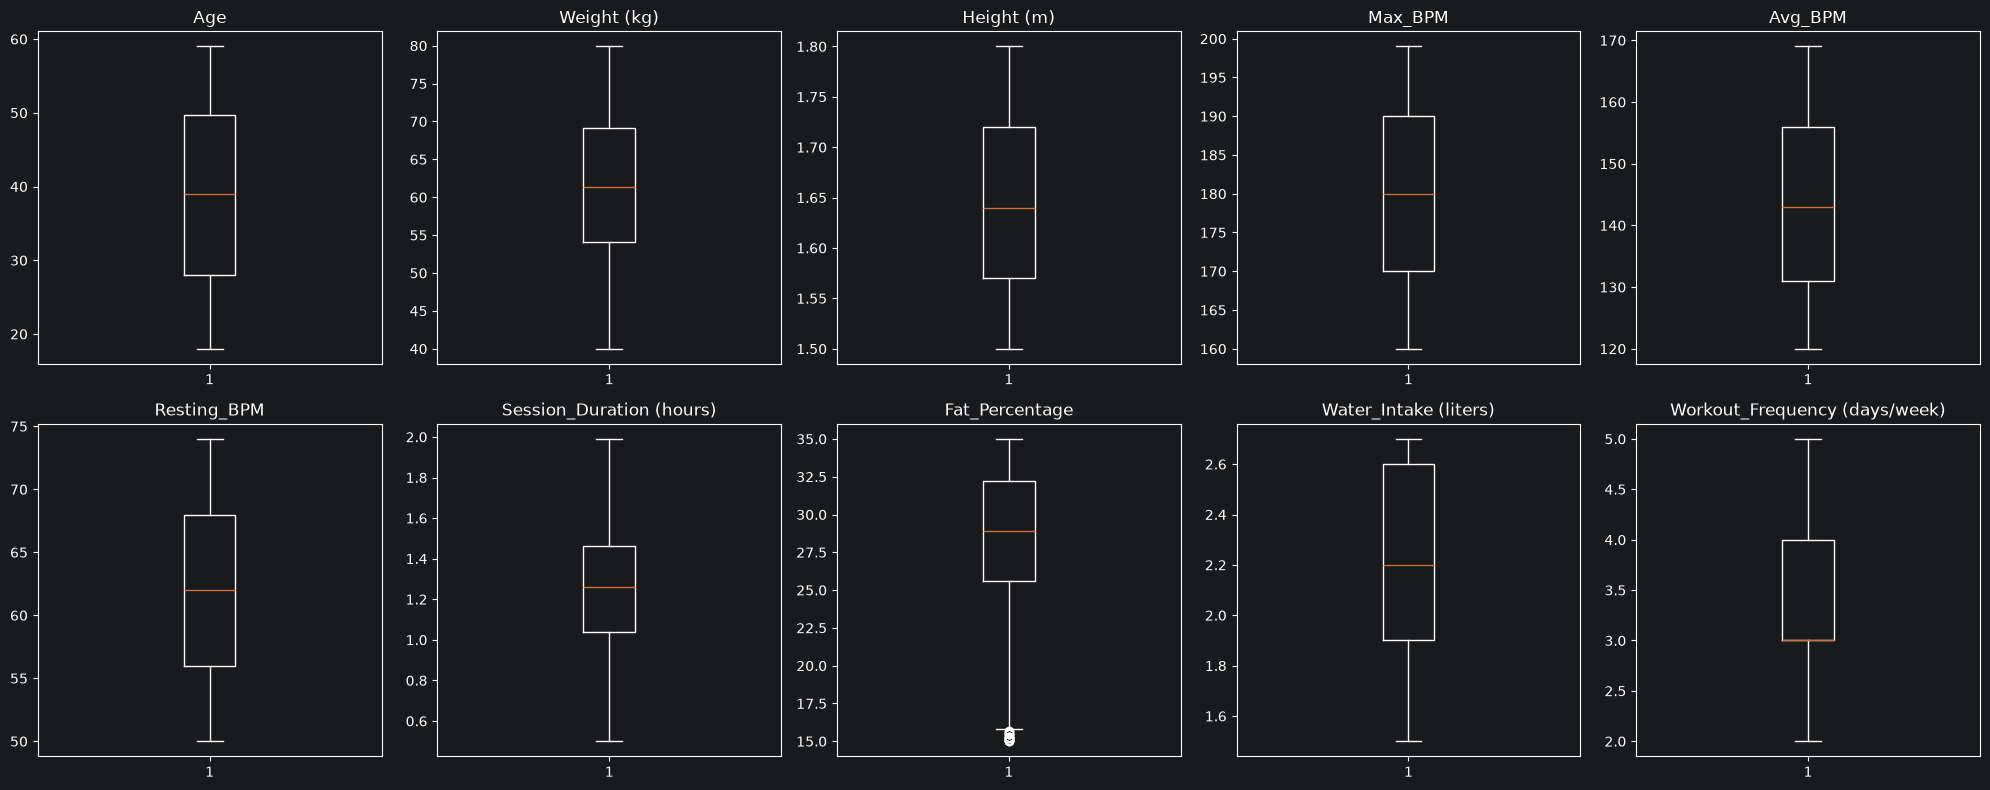

In [9]:
# Sledeće sto želimo da proverimo su outlier-i, pravimo poseban boxplot za svaku promenljivu, jer imaju veoma različite raspone vrednosti (npr. Weight ide do 130, a Height do 2), pa bi ih zajednički prikaz na istoj skali učinio nepreglednim
kolone = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM",
          "Resting_BPM", "Session_Duration (hours)", "Fat_Percentage",
          "Water_Intake (liters)", "Workout_Frequency (days/week)"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

axes = axes.flatten()


for i, kolona in enumerate(kolone):
    axes[i].boxplot(zenski_clanovi[kolona])
    axes[i].set_title(kolona)

plt.tight_layout()
plt.show()

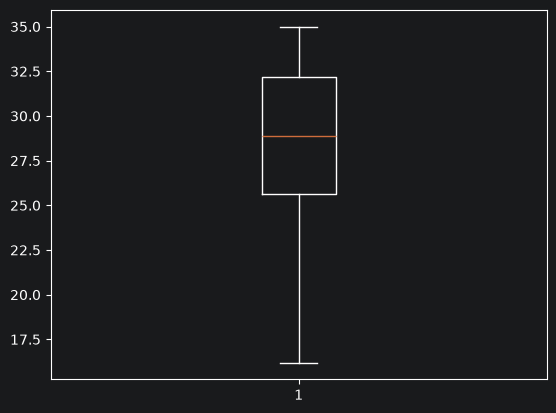

In [10]:
from scipy.stats.mstats import winsorize
import numpy as np
#Vidimo da outlier-i postoje sa donje strane u koloni Fat_Percantage,a ostale kolone izgledaju okej
#Zato ćemo uraditi winsorization za tu promenljivu:

#Odozgo ne želimo ništa da odsecamo jer nemamo gore outlier-e vec dole,tako da je drugi parametar 0
wins = winsorize(zenski_clanovi["Fat_Percentage"], limits = [0.04, 0])

plt.boxplot(wins)
plt.show()

#Kada se uradi winsorize od 0.96 do 0 percentila eliminišu se svi outlier-i


#Zamenjujemo sa winsorize vrednostima, stavljamo np.asarray zbog warning-a jer je funkcija winsorize vratila MaskedArray,pa Pandas izbacuje upozorenje kada kasnije izračunavamo kvantiile unutar .describe()
zenski_clanovi["Fat_Percentage"]=np.asarray(wins)

In [11]:
from sklearn.preprocessing import MinMaxScaler
# Sledeće što je potrebno jeste izvršiti normalizaciju(skaliranje) promenljivih jer su na različitim rasponima vrednosti
# (npr. Weight do 79, Height do 1.8)

#Podaci pre normalizacije:
zenski_clanovi.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week)
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,38.335498,60.939827,1.644242,179.759740,143.621212,62.114719,1.260823,27.687879,2.205411,3.339827
std,12.332962,10.237671,0.086710,11.365199,14.408716,7.247547,0.341950,5.642543,0.388323,0.897873
min,18.000000,40.000000,1.500000,160.000000,120.000000,50.000000,0.500000,16.200000,1.500000,2.000000
25%,28.000000,54.050000,1.570000,170.000000,131.000000,56.000000,1.040000,25.625000,1.900000,3.000000
50%,39.000000,61.350000,1.640000,180.000000,143.000000,62.000000,1.260000,28.900000,2.200000,3.000000
75%,49.750000,69.175000,1.720000,190.000000,156.000000,68.000000,1.460000,32.200000,2.600000,4.000000
max,59.000000,79.900000,1.800000,199.000000,169.000000,74.000000,1.990000,35.000000,2.700000,5.000000


In [12]:
#Podaci nakon normalizacije
zenski_clanovi = pd.DataFrame(MinMaxScaler().fit_transform(zenski_clanovi), columns=zenski_clanovi.columns)
zenski_clanovi.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week)
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,0.495988,0.524808,0.480808,0.506660,0.482066,0.504780,0.510619,0.611057,0.587843,0.446609
std,0.300804,0.256583,0.289033,0.291415,0.294055,0.301981,0.229497,0.300135,0.323603,0.299291
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.243902,0.352130,0.233333,0.256410,0.224490,0.250000,0.362416,0.501330,0.333333,0.333333
50%,0.512195,0.535088,0.466667,0.512821,0.469388,0.500000,0.510067,0.675532,0.583333,0.333333
75%,0.774390,0.731203,0.733333,0.769231,0.734694,0.750000,0.644295,0.851064,0.916667,0.666667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


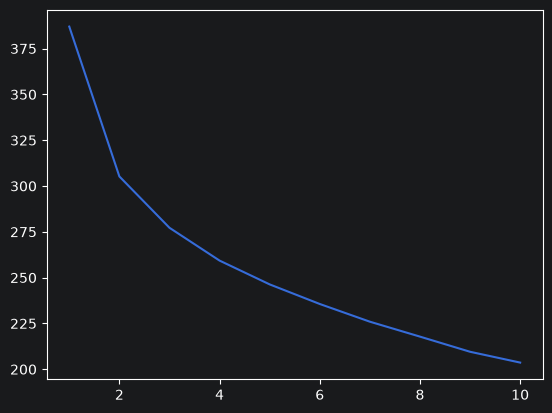

In [13]:
#Kada smo pripremili dataset za klasterizaciju, prvo ćemo obraditi kmeans klasterizaciju i prvo što je potrebno jeste da primenom elbow metode odredimo optimalno k
wcss = []

for i in range(1,11):
    kmeans = cluster.KMeans(n_clusters=i, init="k-means++", n_init= 1000, max_iter=100, random_state=0).fit(zenski_clanovi)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.show()

k=2: silhouette score = 0.2455
k=3: silhouette score = 0.1469
k=4: silhouette score = 0.1390
k=5: silhouette score = 0.1362
k=6: silhouette score = 0.1375
k=7: silhouette score = 0.1410
k=8: silhouette score = 0.1154
k=9: silhouette score = 0.1172
k=10: silhouette score = 0.1177


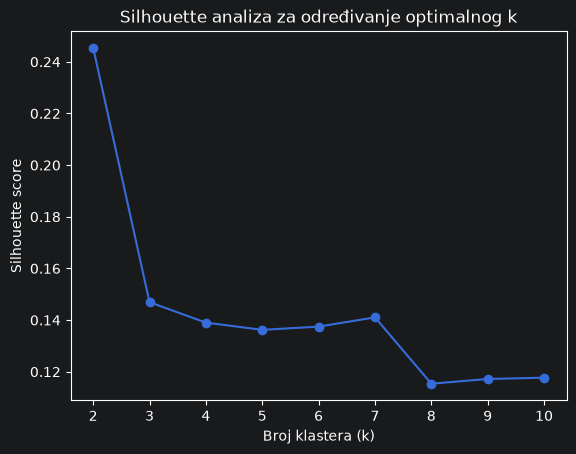

In [14]:
#Pošto elbow metoda ukazuje na k=2 i vidimo blagi lakat na k=3, računamo silhouette score za te i okolne vrednosti k kako bismo imali dodatnu potvrdu izbora optimalnog broja klastera, a ne samo vizuelnu procenu sa grafika

from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = cluster.KMeans(n_clusters=i, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(zenski_clanovi)
    score = silhouette_score(zenski_clanovi, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={i}: silhouette score = {score:.4f}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Broj klastera (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analiza za određivanje optimalnog k")
plt.show()

In [15]:
#Silhouette analiza je potvrdila k=2 kao optimalan broj klastera (score = 0.2455), što je značajno viša vrednost u odnosu na sve ostale ispitane vrednosti k, čime se vidi da k=3 nije bolji izbor uprkos blagom pregibu uočenom na elbow grafiku
#Vršimo klasterizaciju za k=2:
kmeans = cluster.KMeans(n_clusters = 2, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(zenski_clanovi)

zenski_clanovi_clusters = zenski_clanovi.copy()
zenski_clanovi_clusters["cluster"] = kmeans.labels_

zenski_clanovi_clusters.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),cluster
0,0.682927,0.874687,0.100000,0.487179,0.632653,0.666667,0.536913,0.941489,0.500000,0.666667,0
1,0.341463,0.704261,0.533333,0.179487,0.040816,0.166667,0.409396,0.914894,0.666667,0.666667,0
2,0.926829,0.451128,0.600000,0.205128,0.734694,1.000000,0.731544,0.000000,1.000000,1.000000,1
3,0.536585,0.744361,0.033333,0.743590,0.428571,0.583333,0.516779,0.765957,0.333333,0.333333,0
4,0.512195,0.062657,0.833333,0.538462,0.224490,0.083333,0.422819,0.531915,0.500000,0.000000,0


Klaster 1:  370
Klaster 2:  92


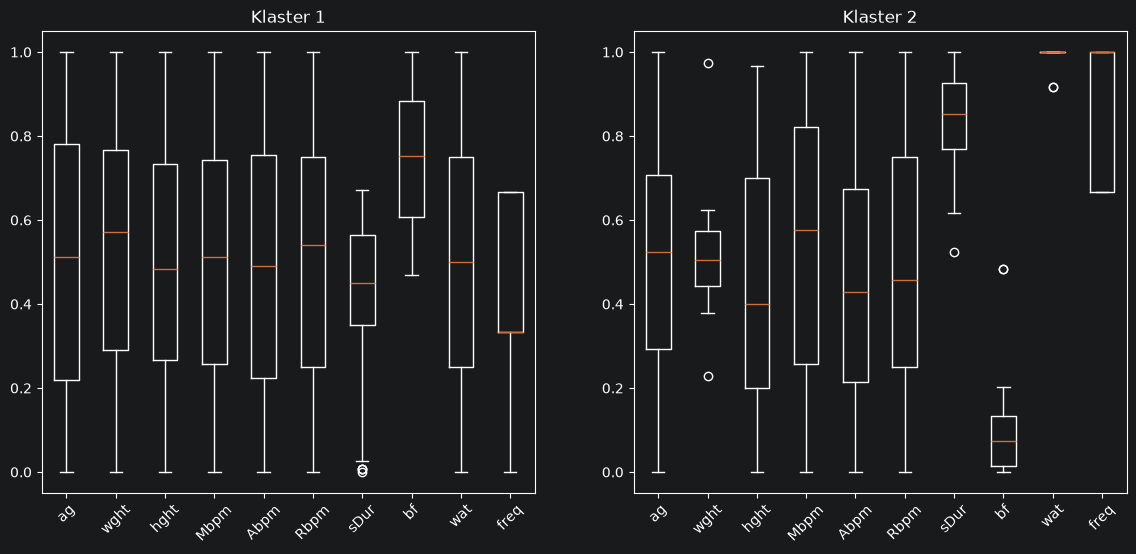

In [16]:
# Nakon klasterizacije za k=2, vršimo tumačenje dobijenih klastera (veličina, centralne vrednosti i disperzija)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].boxplot(zenski_clanovi_clusters[zenski_clanovi_clusters["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(zenski_clanovi_clusters[zenski_clanovi_clusters["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[1].set_title("Klaster 2")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", zenski_clanovi_clusters.loc[zenski_clanovi_clusters["cluster"]==0, "cluster"].count())
print("Klaster 2: ", zenski_clanovi_clusters.loc[zenski_clanovi_clusters["cluster"]==1, "cluster"].count())
#Klasteri su značajne veličine.
# Klaster 1 (370 članica) - umerene vezbačice: umereno trajanje treninga, viši procenat telesne masti i  srednja učestalost treninga.

# Klaster 2 (92 članice) - posvećene vezbačice: isključivo srednje težine,duže trajanje treninga, veoma nizak procenat telesne masti, visoka učestalost treninga i visok unos vode.

# Sto se tiče disperzije, klaster 2 je homogeniji po godinama i težini, sto znači da su članice ovog klastera međusobno sličnije po tim promenljivim. Klaster 1 je raznovrsniji, obuhvata vezbačice šireg raspona godina, težine i navika treninga.

# Isti obrazac kao kod muškaraca - postoji jasna, prepoznatljiva grupa posvećenih vežbača oba pola, koju karakteriše duži trening i nizak procenat masti.

In [17]:
# Poredimo dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),koji nije korišćen u samoj klasterizaciji - ovo nam služi kao provera da li klasteri koje je algoritam sam pronašao imaju smisla
zenski_clanovi_clusters['Experience_Level'] = experience_level.values
pd.crosstab(zenski_clanovi_clusters['cluster'], zenski_clanovi_clusters['Experience_Level'])


# Poređenje sa kolonom Experience_Level pokazuje jako poklapanje, isto kao kod muškaraca. Klaster 1 (370 članica) sadrži samo članice sa Experience_Level 1 i 2 (početnice i srednji nivo), nijedna napredna članica nije u ovom klasteru.Klaster 2 (92 članice) sadrzi 90 od 92 clanice sa Experience_Level 3, što je jako tačno predviđanje.Znači da je algoritam, iako nije imao podatak o iskustvu, sam prepoznao ko su napredne vezbačice samo na osnovu fizičkih parametara i navika treninga (koliko dugo, koliko često i koliko intenzivno treniraju). Ovo dodatno potvrđuje da klasteri imaju realan smisao.

Experience_Level,1,2,3
cluster,,,
0,179,191,0
1,0,2,90


In [18]:
#Iako Silhouette analiza i Elbow metoda pokazuju da je optimalan broj klastera 2, mi ćemo analizirati i slučaj za k=3 i uporediti i te rezultate budući da intuitivno i na osnovu kolone Expirience_Level ima smisla pokušati i izvršiti klasterizaciju za k=3
kmeans = cluster.KMeans(n_clusters = 3, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(zenski_clanovi)

zenski_clanovi_3clusters = zenski_clanovi.copy()
zenski_clanovi_3clusters["cluster"] = kmeans.labels_

zenski_clanovi_3clusters.head(20)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),cluster
0,0.682927,0.874687,0.100000,0.487179,0.632653,0.666667,0.536913,0.941489,0.500000,0.666667,2
1,0.341463,0.704261,0.533333,0.179487,0.040816,0.166667,0.409396,0.914894,0.666667,0.666667,1
2,0.926829,0.451128,0.600000,0.205128,0.734694,1.000000,0.731544,0.000000,1.000000,1.000000,0
3,0.536585,0.744361,0.033333,0.743590,0.428571,0.583333,0.516779,0.765957,0.333333,0.333333,1
4,0.512195,0.062657,0.833333,0.538462,0.224490,0.083333,0.422819,0.531915,0.500000,0.000000,1
5,0.024390,0.601504,0.100000,0.153846,0.959184,0.333333,0.557047,0.723404,0.666667,0.333333,1
6,0.560976,0.095238,0.900000,0.564103,0.918367,0.333333,0.463087,0.835106,0.083333,0.333333,2
7,0.707317,0.671679,0.833333,1.000000,0.530612,0.250000,0.422819,0.882979,0.833333,0.333333,2
8,0.902439,0.882206,0.566667,0.717949,0.959184,0.041667,0.583893,0.478723,0.583333,0.000000,2
9,0.780488,0.776942,0.600000,0.692308,0.836735,0.833333,0.449664,0.898936,0.833333,0.000000,2


Klaster 1:  92
Klaster 2:  175
Klaster 3:  195


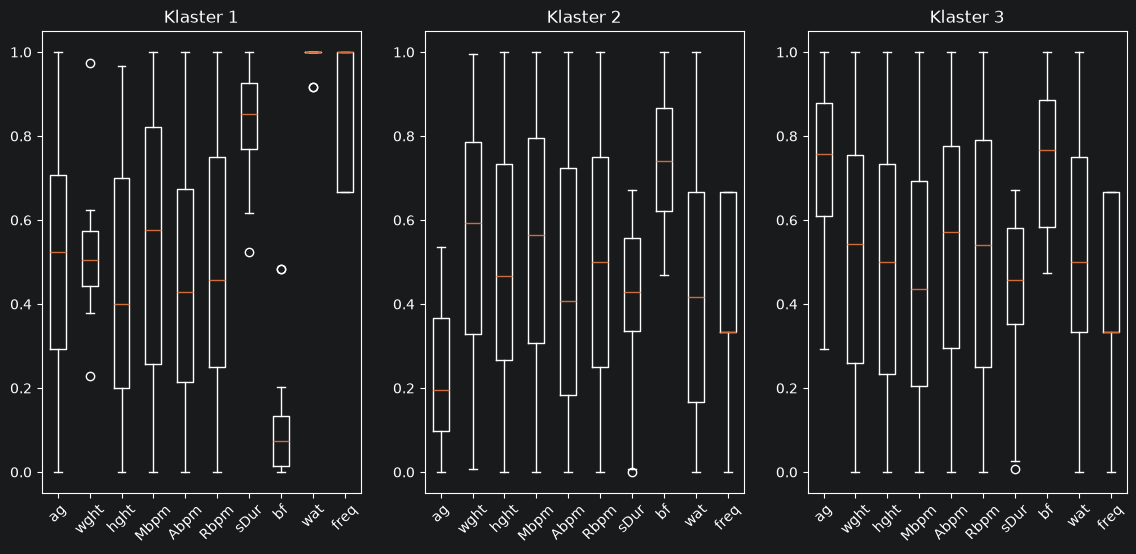

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

ax[0].boxplot(zenski_clanovi_3clusters[zenski_clanovi_3clusters["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(zenski_clanovi_3clusters[zenski_clanovi_3clusters["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[1].set_title("Klaster 2")

ax[2].boxplot(zenski_clanovi_3clusters[zenski_clanovi_3clusters["cluster"]==2].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[2].set_title("Klaster 3")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", zenski_clanovi_3clusters.loc[zenski_clanovi_3clusters["cluster"]==0, "cluster"].count())
print("Klaster 2: ", zenski_clanovi_3clusters.loc[zenski_clanovi_3clusters["cluster"]==1, "cluster"].count())
print("Klaster 3: ", zenski_clanovi_3clusters.loc[zenski_clanovi_3clusters["cluster"]==2, "cluster"].count())

#Svi klasteri su značajne veličine
#Klaster 1(92 članice) čine vežbačice srednjih godina,srednje težine,sa dugim treninzima,niskim procentom telesne masti,visokim unosom vode i visokom frekvencijom treninga-napredne vežbačice.
#Klaster 2(175 članica) čine mlađe vežbačice,srednjeg dužine treninga,visokog procenta telesne masti,nižim i srednjim unosom vode,sa srednjom i malo nižom frekvencijom treninga
#Klaster 3(195 članica) čine starije vežbačice,srednje dužine treninga, visokog procenta telesne masti,nižim i srednjim unosom vode,sa srednjom i malo nižom frekvencijom treninga

#Vidimo dakle da za razliku od muškaraca, ove algoritam klastere je definisao na zanimljiv način, prvi klaster čine napredne vežbačice,a ostala dva klastera su zaprvo slični reklo bi se da su to rekreativne vežbačice,a glavna razlika između njih su godine

In [20]:
# Uporedićemo i ove dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),koji nije korišćen u samoj klasterizaciji
zenski_clanovi_3clusters['Experience_Level'] = experience_level.values
pd.crosstab(zenski_clanovi_3clusters['cluster'], zenski_clanovi_3clusters['Experience_Level'])
# Poredjenje sa Experience_Level pokazuje sličnu sliku kao kod muskaraca za k=3. Klaster 1 (92 članice) skoro potpuno odgovara naprednim vezbačicama (90 od 92 ima Experience_Level 3) isto kao kod k=2 podele.Međutim, Klaster 2 i Klaster 3 gotovo podjednako dele članice sa Experience_Level 1 i 2 (81 i 98, odnosno 94 i 97) - znači da podela između ta dva klastera ne prati nivo iskustva, već neki drugi parametar (verovatno godine).Ovo dodatno potvrđuje da k=2 ostaje bolji izbor i za ženski deo dataseta-jasno razdvaja početnu/srednju od napredne grupe, dok dalja podela na k=3 samo deli tu istu grupu po nekom drugom kriterijumu (godine), što nema veze sa stvarnim nivoom iskustva.

Experience_Level,1,2,3
cluster,,,
0,0,2,90
1,81,94,0
2,98,97,0


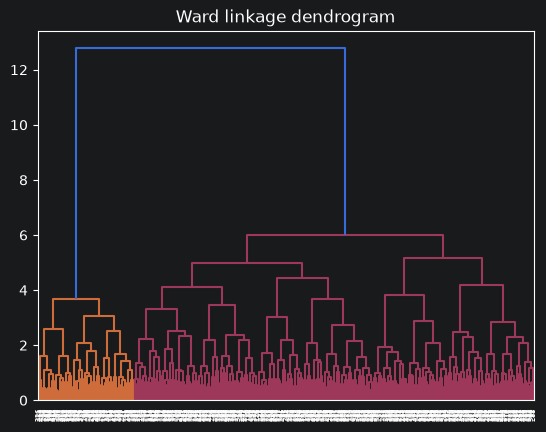

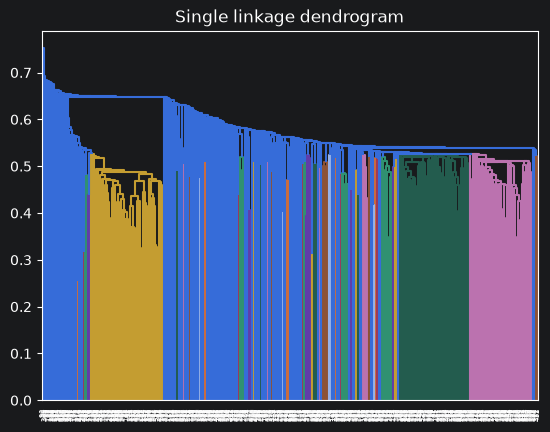

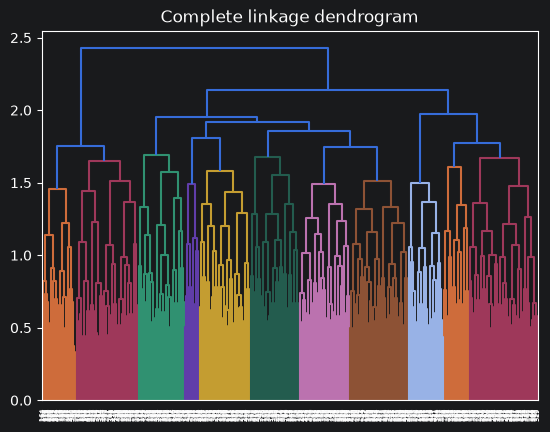

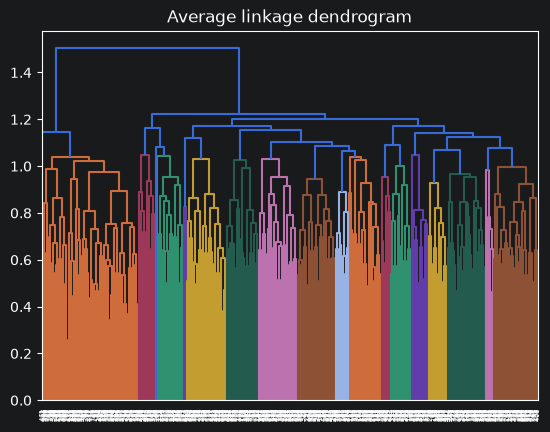

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
#Sada prelazimo na hijarahijsku klasterizaciju, prvo što ćemo uraditi jeste crtanje dendrograma sa različitim linkage metodama i euklidskom razdaljinom i određujemo optimalno k
#Prikaz dendrograma za različite linkage metode:
dendrogram(linkage(zenski_clanovi, method='ward', metric='euclidean'))
plt.title("Ward linkage dendrogram")
plt.show()

dendrogram(linkage(zenski_clanovi, method='single', metric='euclidean'))
plt.title("Single linkage dendrogram")
plt.show()

dendrogram(linkage(zenski_clanovi, method='complete', metric='euclidean'))
plt.title("Complete linkage dendrogram")
plt.show()

dendrogram(linkage(zenski_clanovi, method='average', metric='euclidean'))
plt.title("Average linkage dendrogram")
plt.show()

In [22]:
# Isto kao kod muškog dataseta, od ove 4 metode i opet mi deluje da je najbolja Ward linkage. Single i average linkage prave chaining efekat.Complete linkage opet pravi previše malih grupica.Ward daje najčistiju podelu, sa jasnim razdvajanjem na visini oko 12, i logika mu je slična k-means-u, pa su rezultati lakše uporedivi.

#Radimo hijerarhijsku klasterizaciju sa dva klastera i Ward linkage metodom, euklidska udaljenost
hclust = cluster.AgglomerativeClustering(n_clusters=2, linkage = "ward", metric="euclidean").fit(zenski_clanovi)

# Pravimo novi dataset i dodajemo kolonu sa vrednostima klastera
h_zenski_clanovi = zenski_clanovi.copy()
h_zenski_clanovi["cluster"] = hclust.labels_
h_zenski_clanovi.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),cluster
0,0.682927,0.874687,0.100000,0.487179,0.632653,0.666667,0.536913,0.941489,0.500000,0.666667,0
1,0.341463,0.704261,0.533333,0.179487,0.040816,0.166667,0.409396,0.914894,0.666667,0.666667,0
2,0.926829,0.451128,0.600000,0.205128,0.734694,1.000000,0.731544,0.000000,1.000000,1.000000,1
3,0.536585,0.744361,0.033333,0.743590,0.428571,0.583333,0.516779,0.765957,0.333333,0.333333,0
4,0.512195,0.062657,0.833333,0.538462,0.224490,0.083333,0.422819,0.531915,0.500000,0.000000,0


Klaster 1:  372
Klaster 2:  90


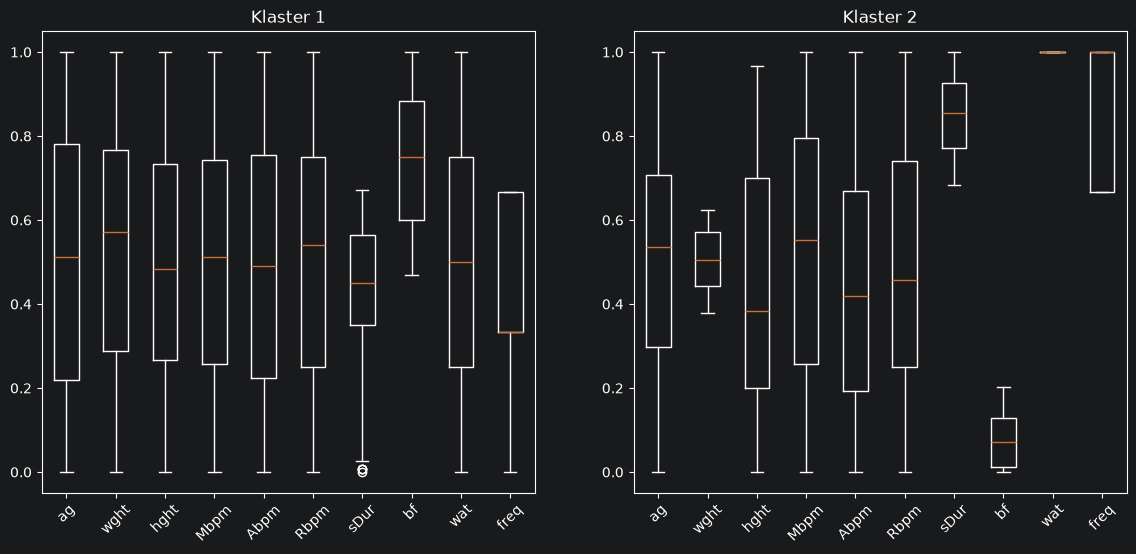

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].boxplot(h_zenski_clanovi[h_zenski_clanovi["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(h_zenski_clanovi[h_zenski_clanovi["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[1].set_title("Klaster 2")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", h_zenski_clanovi.loc[h_zenski_clanovi["cluster"]==0, "cluster"].count())
print("Klaster 2: ", h_zenski_clanovi.loc[h_zenski_clanovi["cluster"]==1, "cluster"].count())

#Klasteri su značajne veličine
#Klaster 1 (372 članice) - umerene vezbacice: umereno trajanje treninga, visi procenat telesne masti, niža do srednja učestalost treninga.

# Klaster 2 (90 članica) - posvećene vezbacice:srednje težine,duže trajanje treninga,veoma nizak procenat telesne masti, veci unos vode i viša učestalost treninga.
#
# Klaster 2 je homogeniji po težini,procentu masti i unosu vode, dok je klaster 1 raznovrsniji po godinama i težini.

In [24]:
# Uporedićemo dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),kao i kada smo završili kMeans klasterizaciju

h_zenski_clanovi['Experience_Level'] = experience_level.values
pd.crosstab(h_zenski_clanovi['cluster'], h_zenski_clanovi['Experience_Level'])

# Poredjenje sa Experience_Level kolonom pokazuje isto što i kod k-means-Klaster 2 je sastavljen iskljucivo od naprednih članica (90 od 90, sve sa Experience_Level 3), dok Klaster 1 sadrži samo početnice i članice sa srednjim nivoom iskustva.Ovo potvrđuje da su i kod hijerarhijske klasterizacije dobijeni klasteri smisleni i da prate stvaran nivo iskustva, iako ta informacija uopste nije koriscena u samoj klasterizaciji.


# Poređenje k-means i hijerarhijske (Ward) klasterizacije za ženski deo dataseta:

# Veličine klastera su gotovo identične (k-means: 370/92, hijerarhijska: 372/90),razlika je svega par članica. Interpretacija klastera je takodje ista kod obe metode: manji klaster (90-92 članice) karakterišu duži i češći treninzi i nizak procenat masti, dok veći klaster (370-372 članice) karakteriše umereno trajanje treninga i viši procenat masti.Obe metode se i kod muškaraca i kod žena slazu oko iste podele, što pokazuje da otkrivena podela nije slučajna, već predstavlja stvarnu podelu članica na osnovu navika treninga i fizičkih parametara.

Experience_Level,1,2,3
cluster,,,
0,179,193,0
1,0,0,90
